In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [2]:
data_files = sorted(Path("./data2d").glob("*.npz"))

In [3]:
df = []
for data_file in data_files:
    data = np.load(data_file, allow_pickle=True)
    params = data["params"].item()
    if "v" in params:
        params["vx"] = params["v"][0]
        params["vy"] = params["v"][1]
        del params["v"]
    z_hist = data["z_hist"]
    df.append(params | {"tseries": z_hist})
df = pd.DataFrame(df)

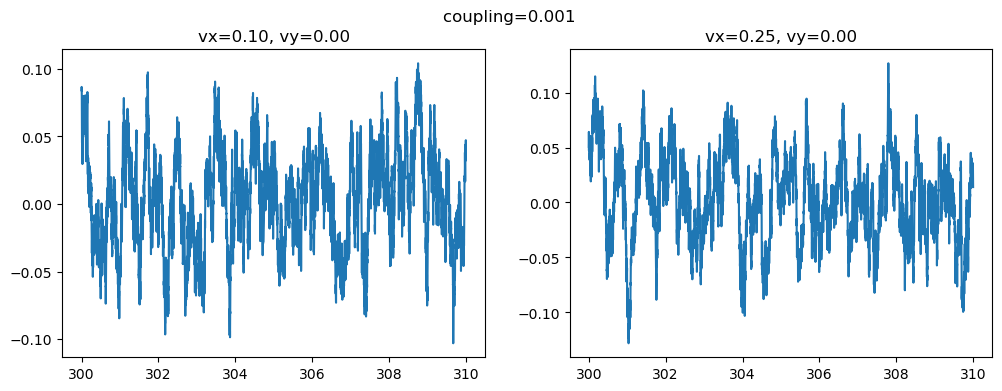

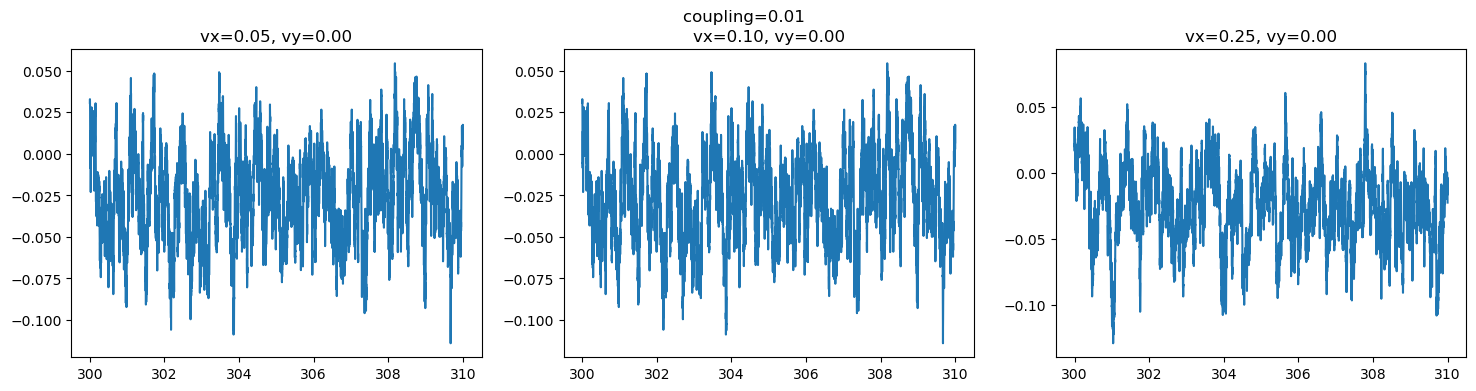

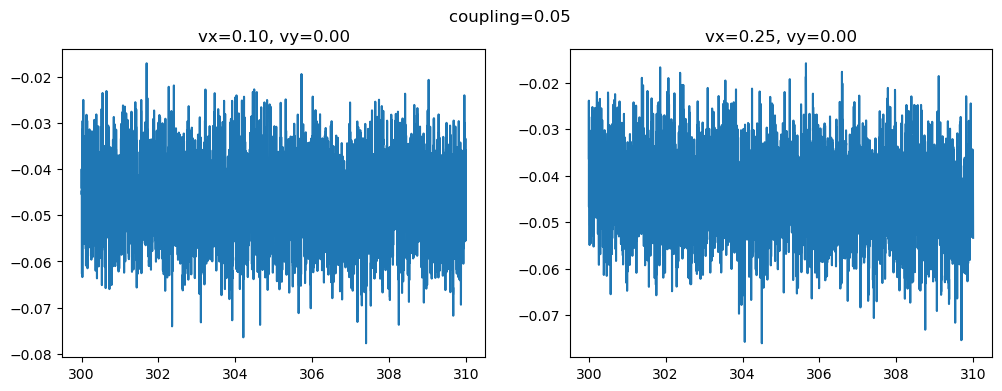

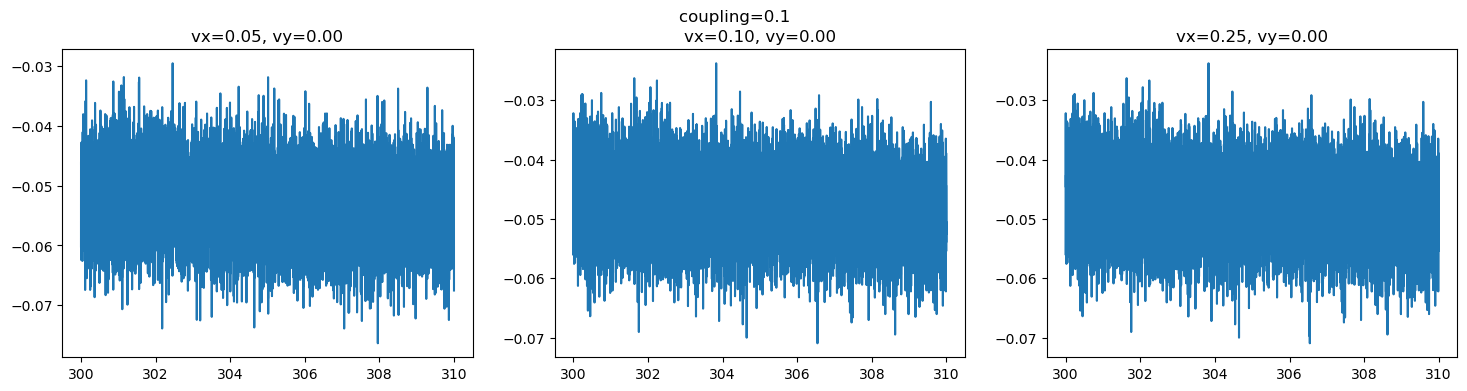

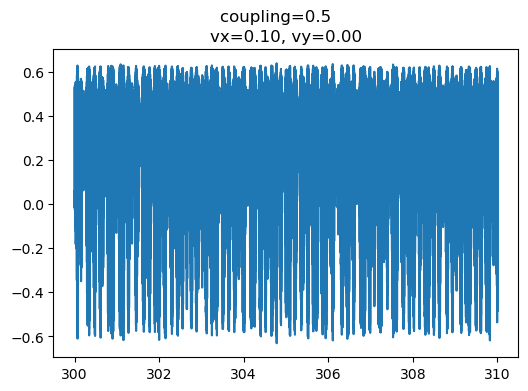

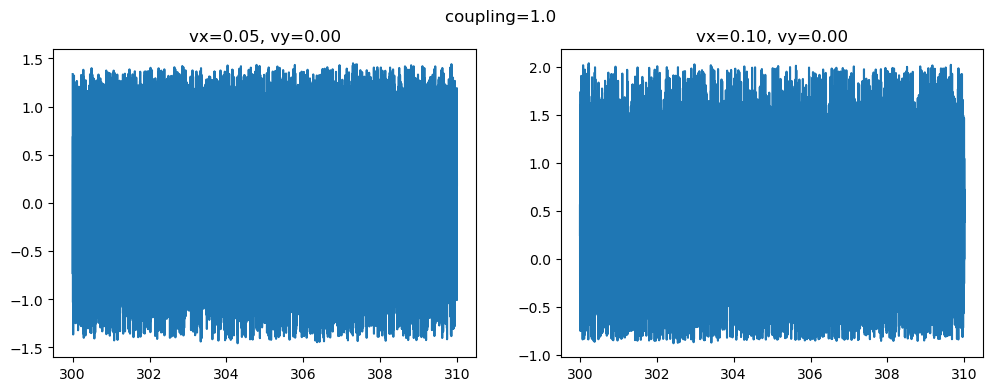

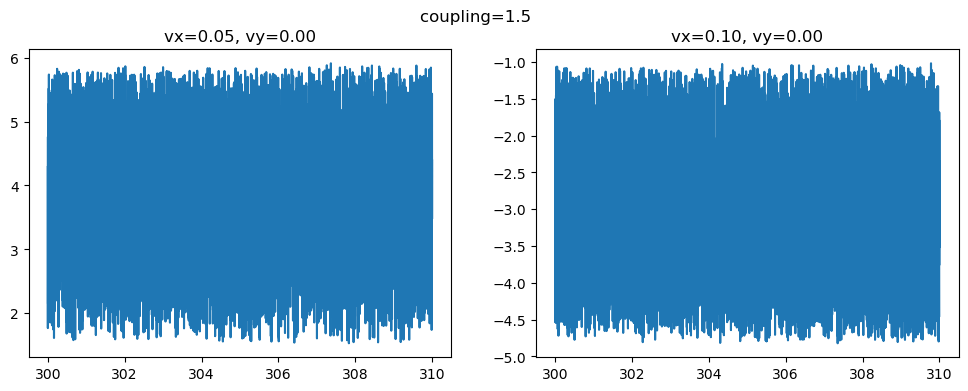

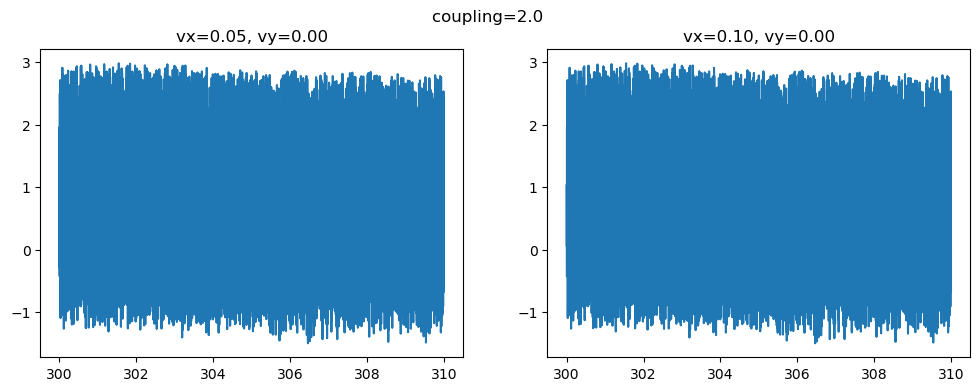

In [5]:
start_time = 300
end_time = start_time + 10
plot_traces = True
for coupling, df_coupling in df.groupby("coupling"):
    num_plots = len(df_coupling)
    df_coupling = df_coupling.sort_values("coupling")
    vels = df_coupling["vx"].values
    fig, axes = plt.subplots(1, num_plots, figsize=(6*num_plots, 4), sharex=plot_traces)
    if num_plots == 1:
        axes = [axes]
    for i, (idx, row) in enumerate(df_coupling.iterrows()):
        tseries = row["tseries"]
        
        time = np.arange(len(tseries))*row["dt"]
        mask = (time >= start_time) & (time < end_time)
        
        x = tseries[mask,0]
        t = time[mask]
        
        if(plot_traces):
            axes[i].plot(t, x, label="x")
        else:
            axes[i].hist(x, bins=100, density=True)
            axes[i].set_yscale("log")
        axes[i].set_title(f"vx={row['vx']:.2f}, vy={row['vy']:.2f}")
    fig.suptitle(f"coupling={row['coupling']} ")
        
    plt.show()